 E-Commerce Analytics Pipeline
==============================================================

What this script does (end-to-end):
1) Loads an e-commerce transactions dataset (Online Retail-like schema)
2) Performs explicit, business-justified data cleaning + validation
3) Runs business-focused EDA and saves professional plots
4) Computes methodologically correct RFM metrics
5) Builds RFM segments + 10 deciles (D1 = top customers)
6) Produces decision-ready tables + a stakeholder-style narrative summary

Why this is "production-quality":
- Reproducible paths & outputs
- Modular functions with clear contracts
- Strong validation and explicit assumptions
- Safe deciling (no "duplicates='drop'" surprises)
- Outliers handled with tagging (not naive deletion)
- Clean tables exported for BI and dashboards

Author note:
- This script intentionally prints non-technical insights after each major step.
- It does NOT assume outcomes. Everything is derived from the dataset provided.

Expected input columns (minimum):
InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
 


## Loaded dataset
--------------
- Rows: 541,909
- Columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

**Business meaning:** We will clean cancellations/returns and invalid lines so RFM/deciles are trustworthy.


## Data Cleaning
-------------
- rows_raw: 541,909
- duplicate_rows_exact: 5,268
- bad_dates_removed: 0
- missing_description_filled: 1,454
- cancellations_removed: 9,251
- missing_customerid_removed: 134,658
- nonpositive_qty_removed: 0
- nonpositive_price_removed: 40
- rows_clean: 392,692

**Business meaning:** Customer value is computed on real purchases (no cancellations/returns contamination).

✅ Exported: outputs/transactions_clean.csv

## Baseline business metrics
-------------------------
- Date range: 2010-12-01 → 2011-12-09 (373 days)
- Customers: 4,338 | Invoices: 18,532 | Countries: 37
- Total revenue: 8,887,208.89 | AOV: 479.56

**Business meaning:** These KPIs anchor performance. Campaigns should move AOV, repeat ra

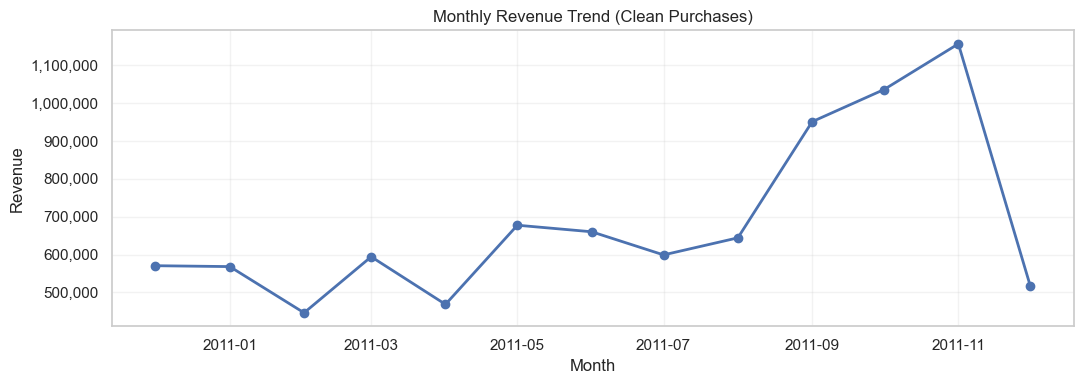

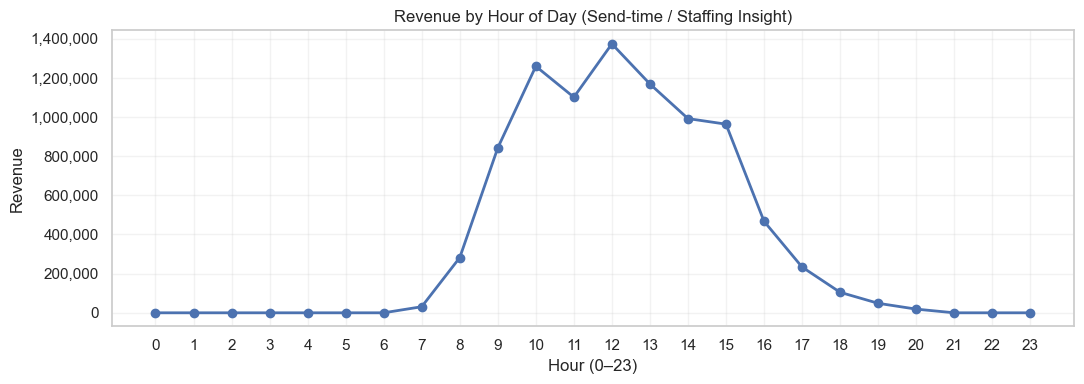

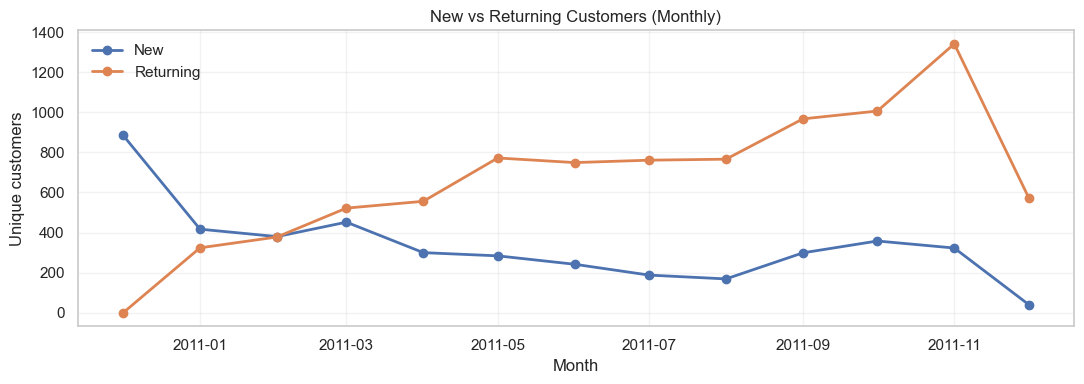

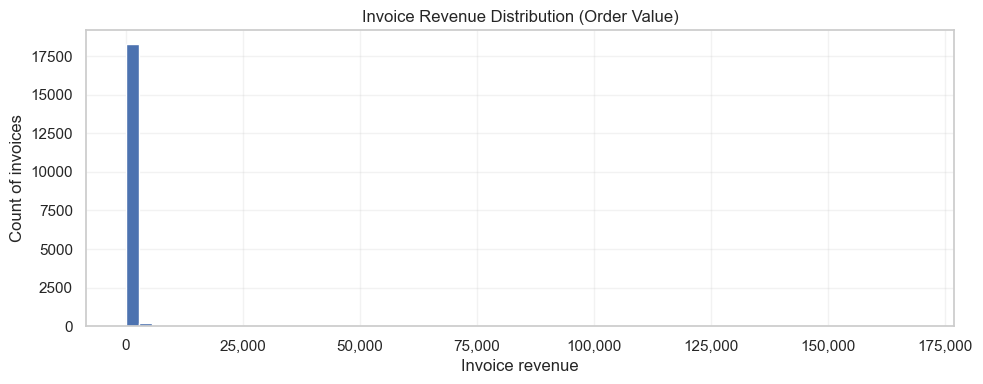

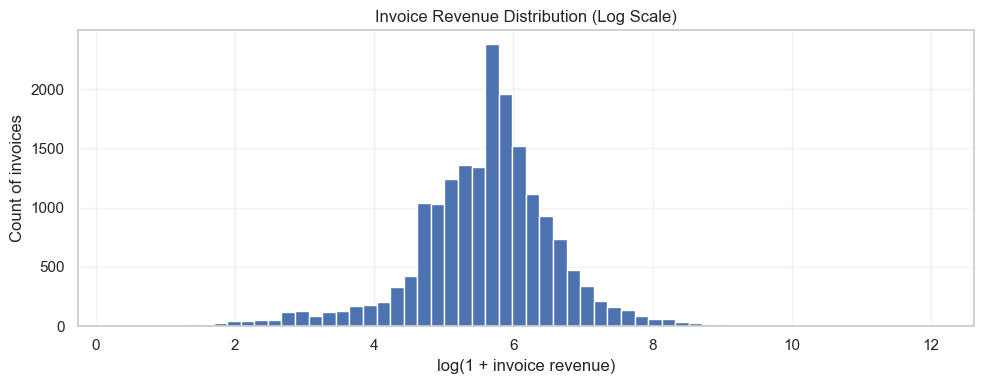

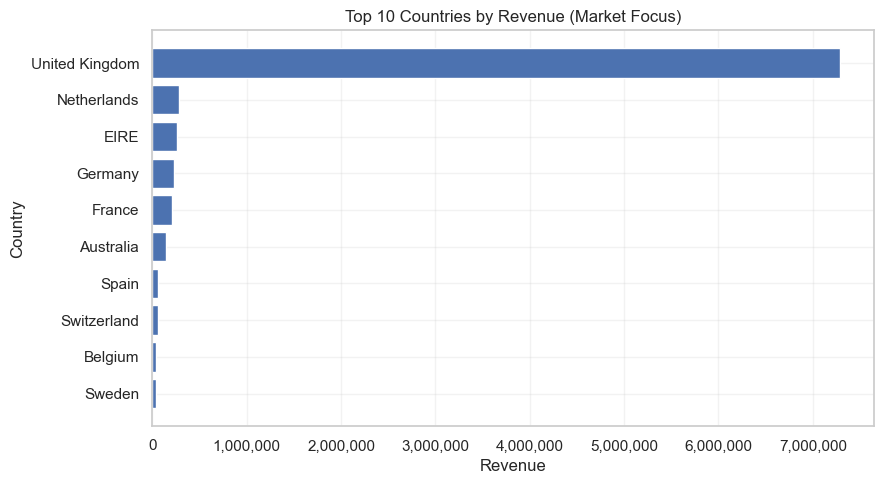

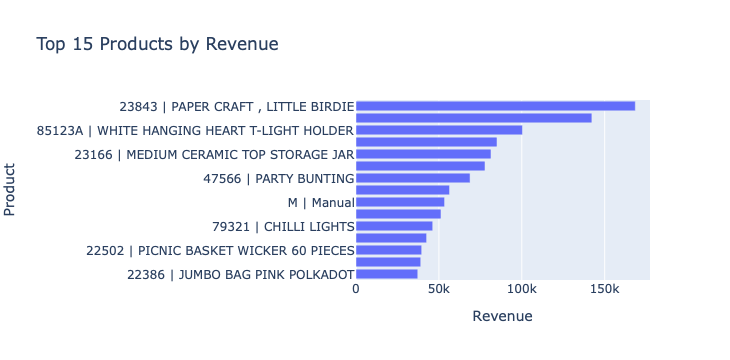

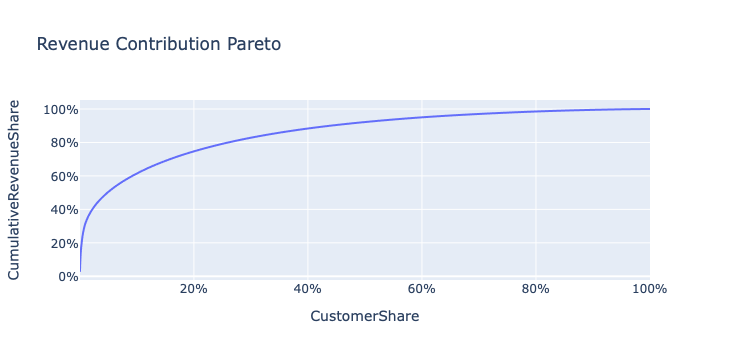

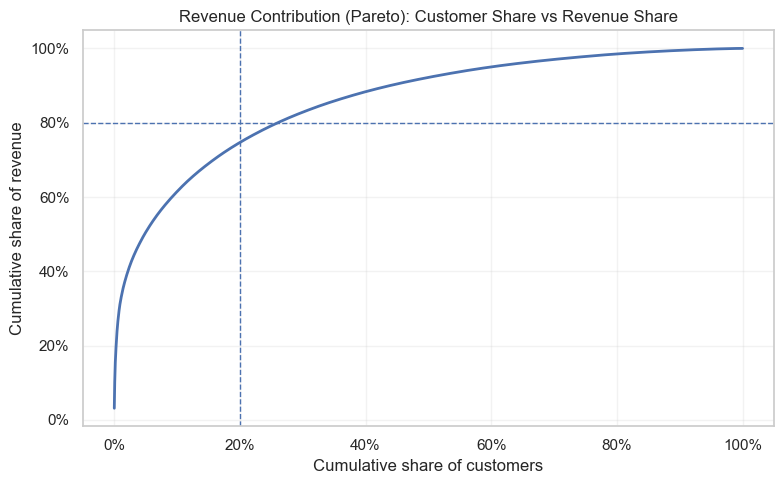


## Revenue concentration (customer contribution)
---------------------------------------------
- Top 1% revenue share: 31.8%
- Top 10% revenue share: 61.5%
- Top 20% revenue share: 74.7%

**Business meaning:** If revenue is concentrated, retention of top deciles often beats blanket discounting.



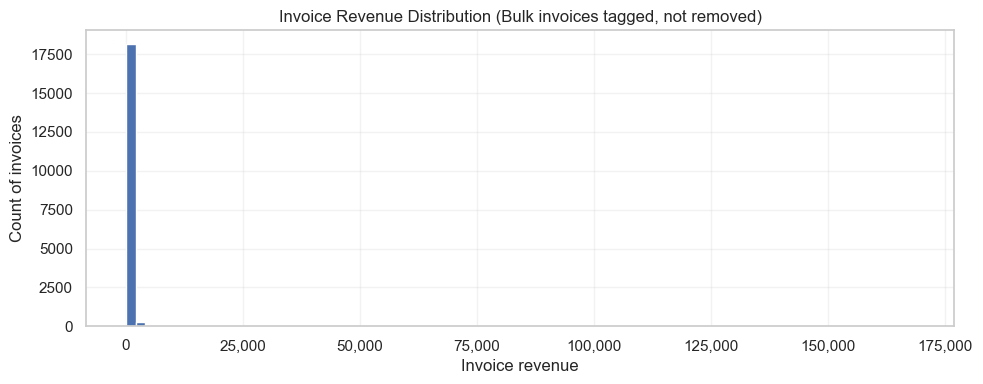


## Bulk / outlier signal (tagged, not deleted)
-------------------------------------------
- Bulk invoice share: 4.1%
- Bulk revenue share: 32.6%

**Business meaning:** Bulk orders might be wholesale/B2B; tagging keeps them visible without biasing analysis.


## Cohort retention (monthly)
--------------------------
This reveals whether newer customer cohorts retain better/worse than older cohorts — it directly informs onboarding, lifecycle messaging, and early win-back strategy.



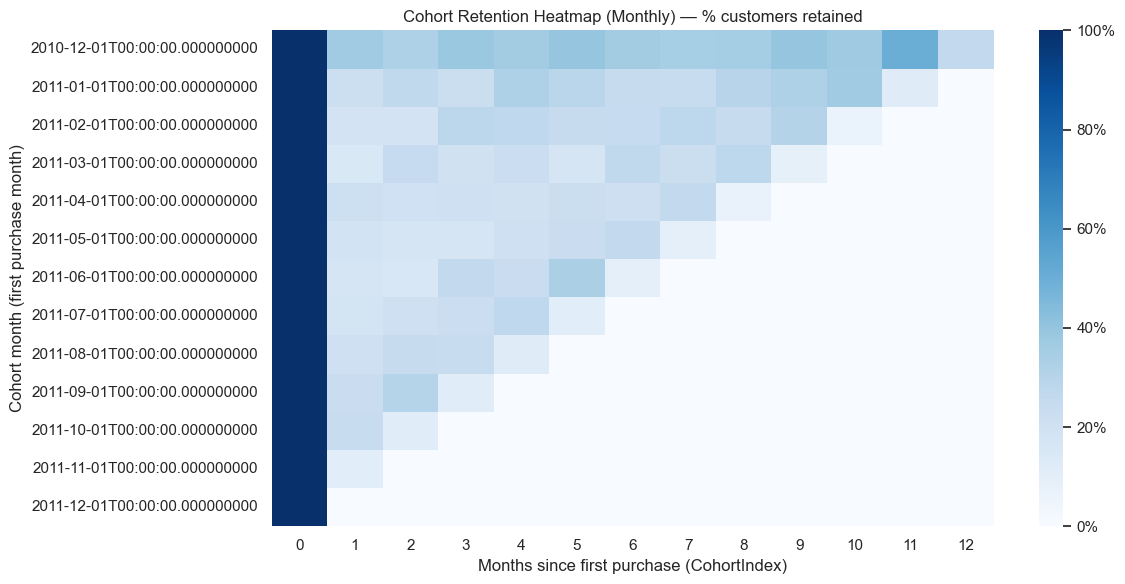

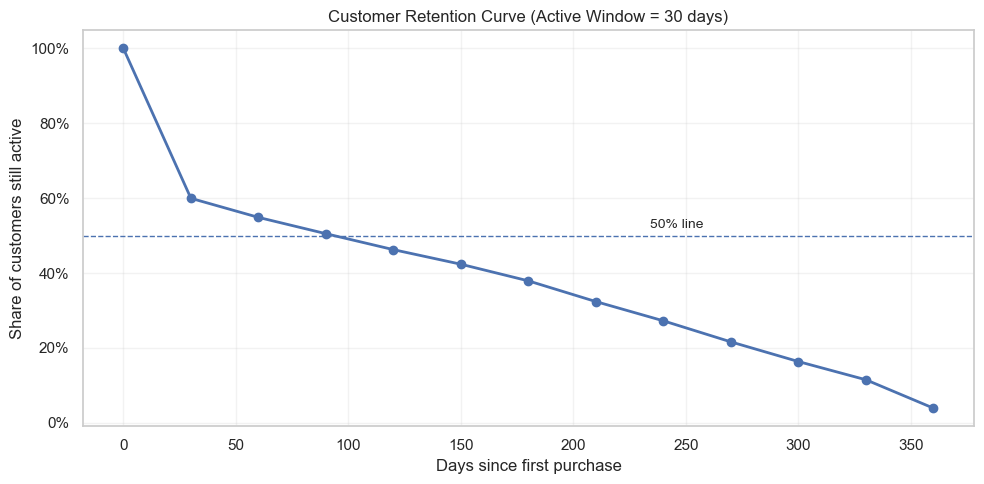


## How to read this chart
----------------------
This curve answers: after acquiring a customer, how quickly do we lose them?
Steeper early drop = weak onboarding / low early value.
Flatter curve = stronger retention and healthier lifecycle.


## Retention curve table (first rows)
----------------------------------
 DaysSinceFirstPurchase  RetentionRate
                      0       1.000000
                     30       0.599585
                     60       0.548640
                     90       0.505071
                    120       0.462425
                    150       0.423467
                    180       0.378976
                    210       0.323651
                    240       0.272245
                    270       0.215998



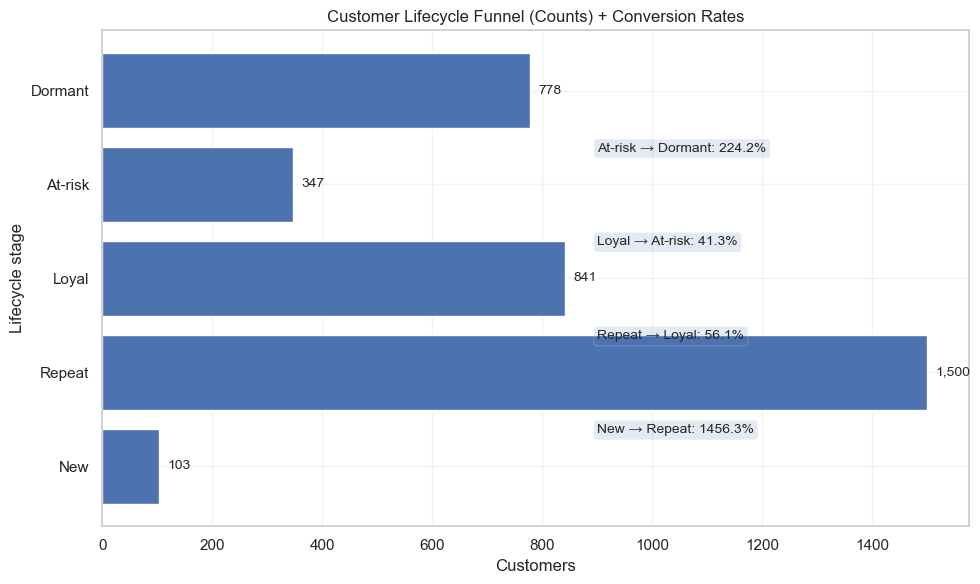


## Lifecycle funnel definitions (data-driven thresholds)
-----------------------------------------------------
- Loyal = Frequency ≥ 6 (top 20% by frequency)
- At-risk = Frequency ≥ 2 AND Recency ≥ 108 (top 30% recency)
- Dormant = Recency ≥ 180 days AND Frequency ≤ 2
- New = Frequency = 1 AND Recency ≤ 18 (bottom 25% recency)


## Lifecycle funnel table
----------------------
Lifecycle  Customers     Revenue  Conversion_to_next
      New        103   32330.850           14.563107
   Repeat       1500 1905517.022            0.560667
    Loyal        841 5807013.340            0.412604
  At-risk        347  454832.240            2.242075
  Dormant        778  376672.841                 NaN

✅ Exported: outputs/rfm_customer_level.csv

## RFM built (methodologically correct)
------------------------------------
- Snapshot date = max InvoiceDate + 1 day
- Recency = days since last purchase
- Frequency = distinct invoices
- Monetary = sum(Quantity × UnitPrice)

**Business meaning:** RFM tu

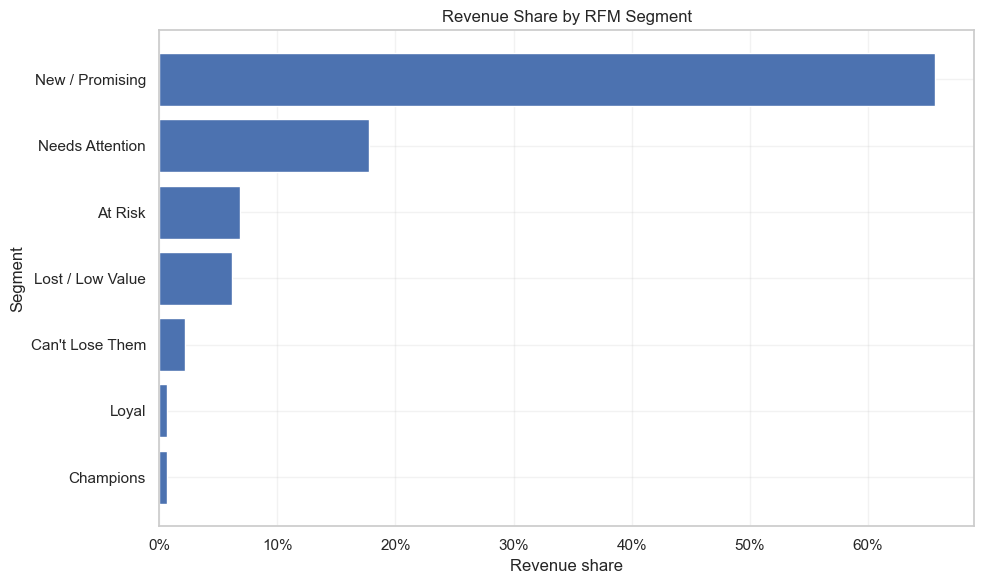


## Decile KPI summary (D1 = top customers)
---------------------------------------
 Decile  Customers     Revenue  Transactions  CustomerShare  RevenueShare  TxnShare  CumulativeRevenueShare  AvgRevenuePerCustomer
      1        434 5461374.890          7211       0.100046      0.614521  0.389111                0.614521           12583.813111
      2        434 1175925.931          2981       0.100046      0.132317  0.160857                0.746837            2709.506753
      3        434  725127.480          2102       0.100046      0.081592  0.113425                0.828430            1670.800645
      4        433  488333.430          1591       0.099816      0.054948  0.085852                0.883378            1127.790831
      5        434  342574.001          1240       0.100046      0.038547  0.066911                0.921925             789.341016
      6        434  251431.681           980       0.100046      0.028291  0.052882                0.950216             579.335671

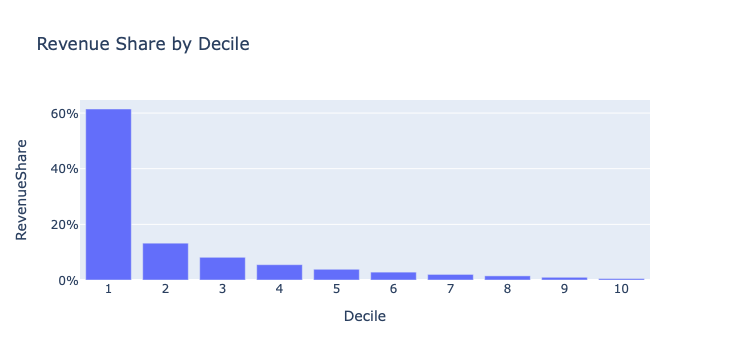

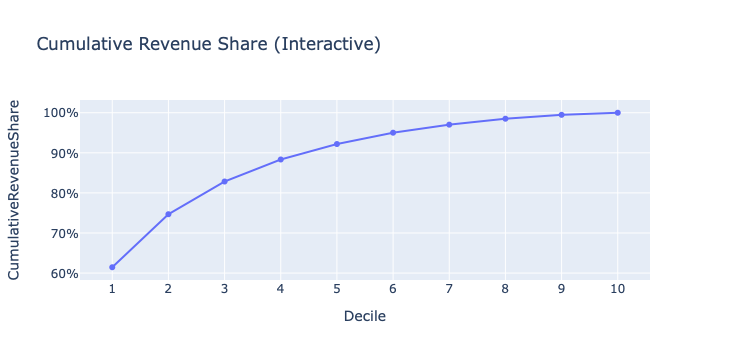

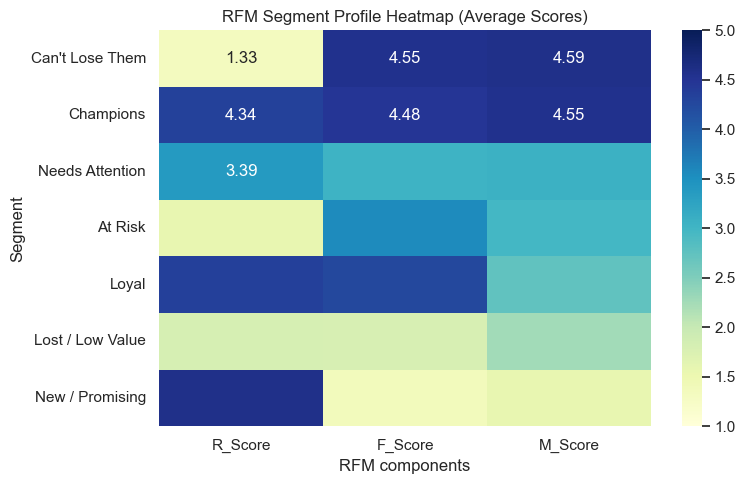

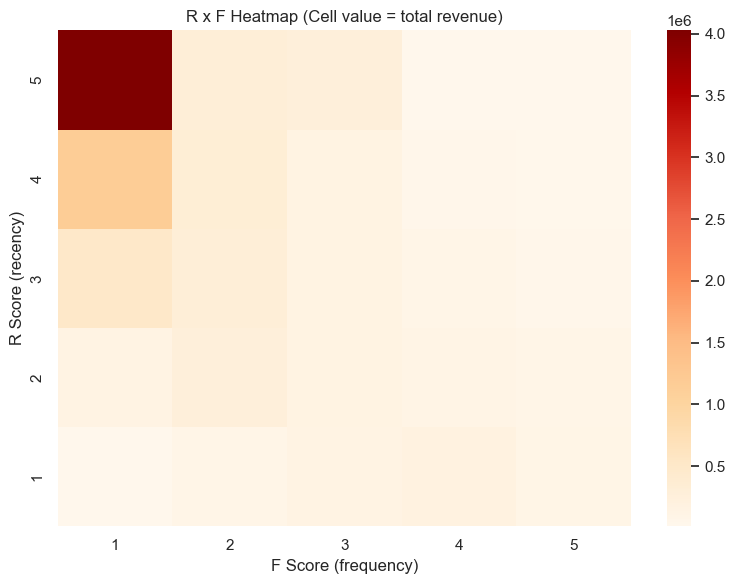


## Business Insights & Actions
---------------------------
### Customer Value
- **D1–D2** contribute **74.7% of revenue** from **20.0% of customers**.
  → VIP retention: early access, concierge support, churn alerts when recency rises.
- **D3–D6** contribute **20.3% of revenue**.
  → Growth tests: cross-sell bundles, threshold shipping, personalization A/B tests.
- **D9–D10** contribute **1.5% of revenue** despite **20.0% of customers**.
  → Low-cost win-back only; suppress chronic non-responders.

### Budget Allocation Framework
- Baseline: allocate spend proportional to revenue share by decile.
- Safeguards: cap touch frequency for D1–D2 (diminishing returns), assign test budget to D3–D6.
- Measure: incremental revenue/customer, reactivation rate, repeat rate (30/60/90d), margin-adjusted ROI.


## Final outputs
-------------
- All charts displayed inline
- Optional CSV exports folder: outputs

**Recruiter note:** This project demonstrates senior analytics: strict cleaning, correct R

In [1]:
from __future__ import annotations

# =========================
# 0) IMPORTING LIBRARIES
# =========================
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Optional: seaborn for nicer heatmaps + styling
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# Optional: plotly for hover/zoom interactive charts
def _try_import_plotly():
    try:
        import plotly.express as px
        return px
    except Exception:
        return None


# =========================
# 1) CONFIG 
# =========================
@dataclass(frozen=True)
class Config:
    # REQUIRED: your dataset path
    data_path: Path = Path('data') / 'data.csv'

    # Exports (safe: will not crash if folder is not writable)
    export_tables: bool = True
    output_dir: Path = Path('outputs')
    # Cleaning rules
    drop_missing_customer: bool = True
    remove_cancellations: bool = True
    require_positive_qty_and_price: bool = True

    # Outlier tagging (invoice-level, avoids deleting VIP/bulk buyers)
    outlier_iqr_multiplier: float = 3.0

    # RFM
    rfm_bins: int = 5
    dormant_days_threshold: int = 180  # ~6 months

    # Visual controls
    top_n_products: int = 15
    top_n_countries: int = 10

    # Use interactive plotly charts if plotly is installed
    prefer_plotly: bool = True


CFG = Config(
    data_path=Path('data')/ 'data.csv',
    export_tables=True,
    output_dir=Path('outputs'),
    prefer_plotly=True,
)


# =========================
# 2) PRINT + EXPORT HELPERS
# =========================
def md_print(title: str, body: str) -> None:
    bar = "-" * len(title)
    print(f"\n## {title}\n{bar}\n{body}\n")


def safe_export(df: pd.DataFrame, cfg: Config, filename: str) -> None:
    """Export CSV if possible; never crashes notebook."""
    if not cfg.export_tables:
        return
    try:
        cfg.output_dir.mkdir(parents=True, exist_ok=True)
        out_path = cfg.output_dir / filename
        df.to_csv(out_path, index=False)
        print(f"✅ Exported: {out_path}")
    except OSError as e:
        print(f"⚠️ Export skipped (cannot write files here): {e}")


# =========================
# 3) PLOTTING STYLE HELPERS
# =========================
def set_plot_theme() -> None:
    """Make charts clean and portfolio-friendly."""
    plt.rcParams.update({
        "figure.figsize": (10, 5),
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    })
    if HAS_SEABORN:
        sns.set_theme(style="whitegrid")


def show_plot() -> None:
    plt.tight_layout()
    plt.show()
    plt.close()


def money_fmt(ax, axis="y"):
    fmt = mtick.FuncFormatter(lambda x, _: f"{x:,.0f}")
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)


def pct_fmt(ax, axis="y"):
    fmt = mtick.PercentFormatter(1.0)
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)


# =========================
# 4) LOAD AND SCHEMA VALIDATION
# =========================
def load_data(cfg: Config) -> pd.DataFrame:
    if not cfg.data_path.exists():
        raise FileNotFoundError(f"Dataset not found:\n{cfg.data_path}")
    return pd.read_csv(cfg.data_path, encoding="ISO-8859-1")


def validate_schema(df: pd.DataFrame) -> None:
    required = {"InvoiceNo", "StockCode", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Dataset missing required columns: {sorted(missing)}")


def parse_invoice_date(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Online Retail-like datasets often parse correctly with dayfirst=False
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce", dayfirst=False)
    return df


# =========================
# 5) CLEANING AND VALIDATION 
# =========================
def clean_data(df_raw: pd.DataFrame, cfg: Config) -> Tuple[pd.DataFrame, Dict[str, int]]:
    """
    Fixes common mistakes from weaker notebooks:
    - Explicit cancellation removal: InvoiceNo starting with 'C'
    - Drops missing CustomerID (customer analytics needs identity)
    - Removes returns/invalid lines: Quantity<=0 or UnitPrice<=0
    - Removes bad dates + exact duplicate rows
    """
    df = df_raw.copy()
    audit: Dict[str, int] = {"rows_raw": len(df)}

    df = parse_invoice_date(df)
    df["InvoiceNo"] = df["InvoiceNo"].astype(str)
    df["StockCode"] = df["StockCode"].astype(str)
    df["Country"] = df["Country"].astype(str)

    df["IsCancellation"] = df["InvoiceNo"].str.upper().str.startswith("C")
    df["BadDate"] = df["InvoiceDate"].isna()
    df["MissingCustomerID"] = df["CustomerID"].isna()
    df["NonPosQty"] = df["Quantity"] <= 0
    df["NonPosPrice"] = df["UnitPrice"] <= 0

    # Exact duplicates
    audit["duplicate_rows_exact"] = int(df.duplicated().sum())
    df = df.drop_duplicates().copy()

    # Bad dates
    audit["bad_dates_removed"] = int(df["BadDate"].sum())
    df = df[~df["BadDate"]].copy()

    # Fill description (if exists) for top-product readability
    if "Description" in df.columns:
        audit["missing_description_filled"] = int(df["Description"].isna().sum())
        df["Description"] = df["Description"].fillna("Unknown")

    # Cancellations (explicit)
    if cfg.remove_cancellations:
        audit["cancellations_removed"] = int(df["IsCancellation"].sum())
        df = df[~df["IsCancellation"]].copy()
    else:
        audit["cancellations_removed"] = 0

    # Missing CustomerID
    if cfg.drop_missing_customer:
        audit["missing_customerid_removed"] = int(df["MissingCustomerID"].sum())
        df = df[~df["MissingCustomerID"]].copy()
    else:
        audit["missing_customerid_removed"] = 0

    # Returns/invalid lines
    if cfg.require_positive_qty_and_price:
        audit["nonpositive_qty_removed"] = int(df["NonPosQty"].sum())
        audit["nonpositive_price_removed"] = int(df["NonPosPrice"].sum())
        df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
    else:
        audit["nonpositive_qty_removed"] = 0
        audit["nonpositive_price_removed"] = 0

    # Normalize CustomerID type
    df["CustomerID"] = df["CustomerID"].astype(float).astype(int)

    # Revenue
    df["Revenue"] = df["Quantity"].astype(float) * df["UnitPrice"].astype(float)

    # Hard safety assertions (correctness)
    assert df["InvoiceDate"].notna().all()
    assert df["CustomerID"].notna().all()
    assert (df["Quantity"] > 0).all()
    assert (df["UnitPrice"] > 0).all()
    assert (df["Revenue"] > 0).all()
    assert ~df["InvoiceNo"].str.upper().str.startswith("C").any()

    audit["rows_clean"] = len(df)
    return df, audit


def tag_bulk_invoices(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Outlier fix: TAG bulk invoices rather than deleting.
    Why: bulk buyers can be your top customers; deleting biases deciles & RFM.
    """
    df = df.copy()
    invoice_rev = df.groupby("InvoiceNo")["Revenue"].sum()

    q1, q3 = invoice_rev.quantile([0.25, 0.75])
    iqr = q3 - q1
    ub = q3 + cfg.outlier_iqr_multiplier * iqr

    bulk_invoices = invoice_rev[invoice_rev > ub].index
    df["IsBulkInvoice"] = df["InvoiceNo"].isin(bulk_invoices)

    df = df.merge(
        invoice_rev.rename("InvoiceRevenue"),
        left_on="InvoiceNo",
        right_index=True,
        how="left",
        validate="many_to_one",
    )
    return df


# =========================
# 6) BUSINESS EDA (ENGAGING)
# =========================
def eda_metrics(df: pd.DataFrame) -> Dict[str, object]:
    inv_rev = df.groupby("InvoiceNo")["Revenue"].sum()
    return {
        "rows": len(df),
        "customers": df["CustomerID"].nunique(),
        "invoices": df["InvoiceNo"].nunique(),
        "products": df["StockCode"].nunique(),
        "countries": df["Country"].nunique(),
        "revenue_total": float(df["Revenue"].sum()),
        "aov": float(inv_rev.mean()),
        "start": df["InvoiceDate"].min(),
        "end": df["InvoiceDate"].max(),
        "span_days": int((df["InvoiceDate"].max() - df["InvoiceDate"].min()).days),
    }


# --- Matplotlib EDA plots ---
def plot_monthly_revenue(df: pd.DataFrame) -> None:
    tmp = df.copy()
    tmp["Month"] = tmp["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
    monthly = tmp.groupby("Month", as_index=False)["Revenue"].sum()

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(monthly["Month"], monthly["Revenue"], marker="o", linewidth=2)
    ax.set_title("Monthly Revenue Trend (Clean Purchases)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Revenue")
    money_fmt(ax, "y")
    show_plot()


def plot_hourly_sales(df: pd.DataFrame) -> None:
    tmp = df.copy()
    tmp["Hour"] = tmp["InvoiceDate"].dt.hour
    hourly = tmp.groupby("Hour")["Revenue"].sum().reindex(range(24), fill_value=0)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(hourly.index, hourly.values, marker="o", linewidth=2)
    ax.set_title("Revenue by Hour of Day (Send-time / Staffing Insight)")
    ax.set_xlabel("Hour (0–23)")
    ax.set_ylabel("Revenue")
    ax.set_xticks(range(0, 24, 1))
    money_fmt(ax, "y")
    show_plot()


def plot_new_vs_returning_customers(df: pd.DataFrame) -> None:
    tmp = df.copy()
    tmp["Month"] = tmp["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

    first_purchase = tmp.groupby("CustomerID")["InvoiceDate"].min()
    first_month = first_purchase.dt.to_period("M").dt.to_timestamp()

    tmp = tmp.merge(first_month.rename("FirstMonth"), left_on="CustomerID", right_index=True, how="left")

    cm = tmp[["CustomerID", "Month", "FirstMonth"]].drop_duplicates()
    cm["CustomerType"] = np.where(cm["Month"] == cm["FirstMonth"], "New", "Returning")

    pivot = (
        cm.groupby(["Month", "CustomerType"])["CustomerID"]
        .nunique()
        .unstack(fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(pivot.index, pivot.get("New", 0), marker="o", linewidth=2, label="New")
    ax.plot(pivot.index, pivot.get("Returning", 0), marker="o", linewidth=2, label="Returning")
    ax.set_title("New vs Returning Customers (Monthly)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Unique customers")
    ax.legend()
    show_plot()


def plot_top_products(df: pd.DataFrame, top_n: int = 15) -> None:
    tmp = df.copy()
    if "Description" in tmp.columns:
        tmp["Product"] = tmp["StockCode"].astype(str) + " | " + tmp["Description"].astype(str)
        col = "Product"
    else:
        col = "StockCode"

    top = (
        tmp.groupby(col)["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index.astype(str), top.values)
    ax.set_title(f"Top {top_n} Products by Revenue (Merchandising Priority)")
    ax.set_xlabel("Revenue")
    ax.set_ylabel("Product")
    money_fmt(ax, "x")
    show_plot()


def plot_top_countries(df: pd.DataFrame, top_n: int = 10) -> None:
    top = (
        df.groupby("Country")["Revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top.index.astype(str), top.values)
    ax.set_title(f"Top {top_n} Countries by Revenue (Market Focus)")
    ax.set_xlabel("Revenue")
    ax.set_ylabel("Country")
    money_fmt(ax, "x")
    show_plot()


def plot_invoice_value_distribution(df: pd.DataFrame) -> None:
    inv = df.groupby("InvoiceNo")["Revenue"].sum()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(inv, bins=60)
    ax.set_title("Invoice Revenue Distribution (Order Value)")
    ax.set_xlabel("Invoice revenue")
    ax.set_ylabel("Count of invoices")
    money_fmt(ax, "x")
    show_plot()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(np.log1p(inv), bins=60)
    ax.set_title("Invoice Revenue Distribution (Log Scale)")
    ax.set_xlabel("log(1 + invoice revenue)")
    ax.set_ylabel("Count of invoices")
    show_plot()


def revenue_contribution_stats_and_plot(df: pd.DataFrame) -> Dict[str, float]:
    cust_rev = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
    cum_rev_share = cust_rev.cumsum() / cust_rev.sum()
    cust_share = np.arange(1, len(cust_rev) + 1) / len(cust_rev)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(cust_share, cum_rev_share.values, linewidth=2)
    ax.set_title("Revenue Contribution (Pareto): Customer Share vs Revenue Share")
    ax.set_xlabel("Cumulative share of customers")
    ax.set_ylabel("Cumulative share of revenue")
    pct_fmt(ax, "x")
    pct_fmt(ax, "y")
    ax.axhline(0.8, linestyle="--", linewidth=1)
    ax.axvline(0.2, linestyle="--", linewidth=1)
    show_plot()

    def top_share(pct: float) -> float:
        n = max(1, int(round(len(cust_rev) * pct)))
        return float(cust_rev.iloc[:n].sum() / cust_rev.sum())

    return {
        "top_1pct_revenue_share": top_share(0.01),
        "top_10pct_revenue_share": top_share(0.10),
        "top_20pct_revenue_share": top_share(0.20),
    }


def plot_bulk_impact(df: pd.DataFrame) -> Dict[str, float]:
    inv = df.groupby("InvoiceNo", as_index=False).agg(
        InvoiceRevenue=("Revenue", "sum"),
        IsBulkInvoice=("IsBulkInvoice", "max"),
    )
    bulk_rev_share = float(inv.loc[inv["IsBulkInvoice"], "InvoiceRevenue"].sum() / inv["InvoiceRevenue"].sum())
    bulk_inv_share = float(inv["IsBulkInvoice"].mean())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(inv["InvoiceRevenue"], bins=80)
    ax.set_title("Invoice Revenue Distribution (Bulk invoices tagged, not removed)")
    ax.set_xlabel("Invoice revenue")
    ax.set_ylabel("Count of invoices")
    money_fmt(ax, "x")
    show_plot()

    return {"bulk_invoice_share": bulk_inv_share, "bulk_revenue_share": bulk_rev_share}

def plot_customer_lifecycle_funnel(rfm: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Customer Lifecycle Funnel (New → Repeat → Loyal → At-risk → Dormant)
    Uses only computed RFM fields (no assumptions).

    Definitions (transparent + defensible):
    - New:       Recency is 'fresh' AND Frequency == 1
    - Repeat:    Frequency >= 2
    - Loyal:     High frequency customers (top ~20% by Frequency)  [data-driven threshold]
    - At-risk:   Previously engaged (Frequency >= 2) BUT Recency is high (top ~30% recency)
    - Dormant:   Recency >= cfg.dormant_days_threshold AND Frequency <= 2

    Note: This is not a single-path state machine (customers can overlap).
    For funnel reporting, we apply them in a priority order to make them mutually exclusive.
    """

    tmp = rfm.copy()

    # Data-driven thresholds (prevents arbitrary hardcoding)
    loyal_freq_threshold = int(np.ceil(tmp["Frequency"].quantile(0.80)))  # top 20% by frequency
    at_risk_recency_threshold = int(np.ceil(tmp["Recency"].quantile(0.70)))  # high recency = top 30%

    # Mutually exclusive lifecycle assignment (priority order)
    tmp["Lifecycle"] = "Other"

    # 1) Dormant (strongest signal)
    dormant_mask = (tmp["Recency"] >= cfg.dormant_days_threshold) & (tmp["Frequency"] <= 2)
    tmp.loc[dormant_mask, "Lifecycle"] = "Dormant"

    # 2) At-risk (engaged historically but long time since last purchase)
    at_risk_mask = (tmp["Lifecycle"] == "Other") & (tmp["Frequency"] >= 2) & (tmp["Recency"] >= at_risk_recency_threshold)
    tmp.loc[at_risk_mask, "Lifecycle"] = "At-risk"

    # 3) Loyal (very frequent buyers)
    loyal_mask = (tmp["Lifecycle"] == "Other") & (tmp["Frequency"] >= loyal_freq_threshold)
    tmp.loc[loyal_mask, "Lifecycle"] = "Loyal"

    # 4) Repeat (2+ purchases but not in loyal/at-risk/dormant)
    repeat_mask = (tmp["Lifecycle"] == "Other") & (tmp["Frequency"] >= 2)
    tmp.loc[repeat_mask, "Lifecycle"] = "Repeat"

    # 5) New (single purchase and very recent) — define "very recent" as bottom 25% recency
    new_recency_threshold = int(np.ceil(tmp["Recency"].quantile(0.25)))
    new_mask = (tmp["Lifecycle"] == "Other") & (tmp["Frequency"] == 1) & (tmp["Recency"] <= new_recency_threshold)
    tmp.loc[new_mask, "Lifecycle"] = "New"

    # Funnel order
    order = ["New", "Repeat", "Loyal", "At-risk", "Dormant"]
    funnel = (
        tmp[tmp["Lifecycle"].isin(order)]
        .groupby("Lifecycle", as_index=False)
        .agg(Customers=("CustomerID", "nunique"), Revenue=("Monetary", "sum"))
    )
    funnel["Lifecycle"] = pd.Categorical(funnel["Lifecycle"], categories=order, ordered=True)
    funnel = funnel.sort_values("Lifecycle")

    # Ensure all stages exist
    for stage in order:
        if stage not in funnel["Lifecycle"].astype(str).values:
            funnel = pd.concat([funnel, pd.DataFrame({"Lifecycle":[stage], "Customers":[0], "Revenue":[0.0]})], ignore_index=True)
    funnel["Lifecycle"] = pd.Categorical(funnel["Lifecycle"], categories=order, ordered=True)
    funnel = funnel.sort_values("Lifecycle").reset_index(drop=True)

    # Conversion rates between consecutive stages
    funnel["Conversion_to_next"] = np.nan
    for i in range(len(order) - 1):
        a = funnel.loc[funnel["Lifecycle"] == order[i], "Customers"].values[0]
        b = funnel.loc[funnel["Lifecycle"] == order[i+1], "Customers"].values[0]
        funnel.loc[funnel["Lifecycle"] == order[i], "Conversion_to_next"] = (b / a) if a > 0 else np.nan

    # Plot funnel as horizontal bars + annotated conversion rates
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(funnel["Lifecycle"].astype(str), funnel["Customers"])

    ax.set_title("Customer Lifecycle Funnel (Counts) + Conversion Rates")
    ax.set_xlabel("Customers")
    ax.set_ylabel("Lifecycle stage")

    # Labels
    for i, row in funnel.iterrows():
        ax.text(row["Customers"] + max(funnel["Customers"].max() * 0.01, 1), i, f"{int(row['Customers']):,}", va="center", fontsize=10)

    # Conversion text (between bars)
    for i in range(len(order) - 1):
        stage = order[i]
        conv = funnel.loc[funnel["Lifecycle"] == stage, "Conversion_to_next"].values[0]
        if not np.isnan(conv):
            ax.text(
                funnel["Customers"].max() * 0.6,
                i + 0.35,
                f"{stage} → {order[i+1]}: {conv:.1%}",
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.25", alpha=0.15)
            )

    plt.tight_layout()
    plt.show()
    plt.close()

    md_print(
        "Lifecycle funnel definitions (data-driven thresholds)",
        f"- Loyal = Frequency ≥ {loyal_freq_threshold} (top 20% by frequency)\n"
        f"- At-risk = Frequency ≥ 2 AND Recency ≥ {at_risk_recency_threshold} (top 30% recency)\n"
        f"- Dormant = Recency ≥ {cfg.dormant_days_threshold} days AND Frequency ≤ 2\n"
        f"- New = Frequency = 1 AND Recency ≤ {new_recency_threshold} (bottom 25% recency)"
    )

    return funnel





# =========================
# 7) COHORT ANALYSIS + HEATMAP
# =========================
def build_monthly_cohort_tables(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cohort retention (monthly):
    - CohortMonth = customer's first purchase month
    - CohortIndex = months since first purchase
    Returns:
      cohort_counts_pivot: active customers per cohort x months-since
      cohort_retention: retention rates (normalized by cohort size)
    """
    tmp = df.copy()
    tmp["OrderMonth"] = tmp["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

    first_purchase = tmp.groupby("CustomerID")["InvoiceDate"].min()
    tmp = tmp.merge(first_purchase.rename("FirstPurchaseDate"), left_on="CustomerID", right_index=True, how="left")
    tmp["CohortMonth"] = tmp["FirstPurchaseDate"].dt.to_period("M").dt.to_timestamp()

    tmp["CohortIndex"] = (
        (tmp["OrderMonth"].dt.year - tmp["CohortMonth"].dt.year) * 12
        + (tmp["OrderMonth"].dt.month - tmp["CohortMonth"].dt.month)
    ).astype(int)

    # Customer-month unique to avoid double-counts
    cm = tmp[["CustomerID", "CohortMonth", "OrderMonth", "CohortIndex"]].drop_duplicates()

    cohort_counts = (
        cm.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
        .nunique()
        .reset_index()
        .rename(columns={"CustomerID": "ActiveCustomers"})
    )

    cohort_counts_pivot = cohort_counts.pivot(
        index="CohortMonth", columns="CohortIndex", values="ActiveCustomers"
    ).fillna(0)

    cohort_size = cohort_counts_pivot[0].replace(0, np.nan)
    cohort_retention = cohort_counts_pivot.div(cohort_size, axis=0)

    return cohort_counts_pivot, cohort_retention


def plot_cohort_retention_heatmap(cohort_retention: pd.DataFrame) -> None:
    if not HAS_SEABORN:
        md_print("Cohort heatmap skipped", "Install seaborn to show cohort heatmap: pip install seaborn")
        return

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        cohort_retention,
        annot=False,
        cmap="Blues",
        cbar_kws={"format": mtick.PercentFormatter(1.0)},
        vmin=0, vmax=min(1.0, float(np.nanmax(cohort_retention.values)))
    )
    plt.title("Cohort Retention Heatmap (Monthly) — % customers retained")
    plt.xlabel("Months since first purchase (CohortIndex)")
    plt.ylabel("Cohort month (first purchase month)")
    plt.tight_layout()
    plt.show()
    plt.close()
    
    

def plot_customer_retention_curve(df: pd.DataFrame, active_window_days: int = 30) -> pd.DataFrame:
    """
    Customer Retention Curve (survival-style)
    Business question: After a customer’s first purchase, how long do they stay active?

    Method (simple + defensible):
    - FirstPurchaseDate per customer
    - LastPurchaseDate per customer
    - ActiveDurationDays = days between first and last purchase
    - Retention(t) = % customers with ActiveDurationDays >= t
    - 'active_window_days' sets a practical time step (default: 30 days ~ monthly)

    Output:
    - A dataframe of retention over time (days since first purchase)
    """
    
    
    cust = (
        df.groupby("CustomerID")
        .agg(FirstPurchase=("InvoiceDate", "min"),
             LastPurchase=("InvoiceDate", "max"),
             Orders=("InvoiceNo", "nunique"),
             Revenue=("Revenue", "sum"))
        .reset_index()
    )

    cust["ActiveDurationDays"] = (cust["LastPurchase"] - cust["FirstPurchase"]).dt.days.astype(int)

    # Build time grid
    max_days = int(cust["ActiveDurationDays"].max())
    if max_days <= 0:
        md_print("Retention curve skipped", "Not enough purchase span to build a retention curve.")
        return pd.DataFrame()

    time_grid = np.arange(0, max_days + 1, active_window_days)

    # Survival-style retention: % with duration >= t
    retention = []
    n = len(cust)
    for t in time_grid:
        retention.append((cust["ActiveDurationDays"] >= t).mean())

    ret_df = pd.DataFrame({"DaysSinceFirstPurchase": time_grid, "RetentionRate": retention})

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ret_df["DaysSinceFirstPurchase"], ret_df["RetentionRate"], marker="o", linewidth=2)

    ax.set_title(f"Customer Retention Curve (Active Window = {active_window_days} days)")
    ax.set_xlabel("Days since first purchase")
    ax.set_ylabel("Share of customers still active")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Helpful reference lines
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.text(ret_df["DaysSinceFirstPurchase"].max() * 0.65, 0.52, "50% line", fontsize=10)

    plt.tight_layout()
    plt.show()
    plt.close()

    md_print(
        "How to read this chart",
        "This curve answers: after acquiring a customer, how quickly do we lose them?\n"
        "Steeper early drop = weak onboarding / low early value.\n"
        "Flatter curve = stronger retention and healthier lifecycle."
    )

    return ret_df






# =========================
# 8) RFM
# =========================
def compute_rfm(df: pd.DataFrame) -> pd.DataFrame:
    """
    Correct RFM:
    - snapshot_date = max InvoiceDate + 1 day
    - Recency = days since last purchase
    - Frequency = distinct invoices
    - Monetary = sum(Quantity * UnitPrice)
    """
    snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    rfm = df.groupby("CustomerID").agg(
        LastPurchase=("InvoiceDate", "max"),
        FirstPurchase=("InvoiceDate", "min"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    ).reset_index()

    rfm["Recency"] = (snapshot_date - rfm["LastPurchase"]).dt.days.astype(int)
    rfm["TenureDays"] = (rfm["LastPurchase"] - rfm["FirstPurchase"]).dt.days.astype(int)
    rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"].replace(0, np.nan)

    assert (rfm["Recency"] >= 0).all()
    assert (rfm["Frequency"] > 0).all()
    assert (rfm["Monetary"] > 0).all()
    return rfm


def qcut_score_safe(series: pd.Series, q: int, ascending: bool) -> pd.Series:
    """
    Fixes the common qcut pitfall with duplicates:
    - rank(method='first') avoids bin collapse from ties
    """
    ranked = series.rank(method="first", ascending=ascending)
    bins = pd.qcut(ranked, q=q, labels=False)
    return (bins + 1).astype(int)  # 1..q


def score_rfm(rfm: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rfm = rfm.copy()
    q = cfg.rfm_bins

    r_raw = qcut_score_safe(rfm["Recency"], q=q, ascending=True)
    rfm["R_Score"] = (q + 1 - r_raw).astype(int)  # invert so 5 = best recency

    rfm["F_Score"] = qcut_score_safe(rfm["Frequency"], q=q, ascending=False).astype(int)
    rfm["M_Score"] = qcut_score_safe(rfm["Monetary"], q=q, ascending=False).astype(int)

    rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
    return rfm


def segment_rfm(rfm: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    rfm = rfm.copy()

    def seg(row) -> str:
        R, F, M = row["R_Score"], row["F_Score"], row["M_Score"]
        rec, freq = row["Recency"], row["Frequency"]

        if R >= 4 and F >= 4 and M >= 4:
            return "Champions"
        if R >= 4 and F >= 4:
            return "Loyal"
        if R >= 4 and F <= 2 and M <= 3:
            return "New / Promising"
        if R <= 2 and F >= 4 and M >= 4:
            return "Can't Lose Them"
        if R <= 2 and F >= 3:
            return "At Risk"
        if rec >= cfg.dormant_days_threshold and freq <= 2:
            return "Dormant / Hibernating"
        if R <= 2 and F <= 2:
            return "Lost / Low Value"
        return "Needs Attention"

    rfm["Segment"] = rfm.apply(seg, axis=1)
    return rfm


# =========================
# 9) RFM HEATMAPS (HIGH-SIGNAL)
# =========================
def plot_rfm_segment_profile_heatmap(rfm: pd.DataFrame) -> None:
    """
    Heatmap of avg R, F, M scores by segment.
    Explains segment behavior clearly to stakeholders/recruiters.
    """
    if not HAS_SEABORN:
        md_print("RFM segment heatmap skipped", "Install seaborn: pip install seaborn")
        return

    prof = (
        rfm.groupby("Segment")[["R_Score", "F_Score", "M_Score"]]
        .mean()
        .sort_values("M_Score", ascending=False)
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(prof, annot=True, fmt=".2f", cmap="YlGnBu", vmin=1, vmax=5)
    plt.title("RFM Segment Profile Heatmap (Average Scores)")
    plt.xlabel("RFM components")
    plt.ylabel("Segment")
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_r_f_monetary_heatmap(rfm: pd.DataFrame) -> None:
    """
    Heatmap: rows=R score, cols=F score, cell value = total monetary.
    Shows which behavior combos generate the most revenue.
    """
    if not HAS_SEABORN:
        md_print("R x F heatmap skipped", "Install seaborn: pip install seaborn")
        return

    grid = (
        rfm.groupby(["R_Score", "F_Score"])["Monetary"]
        .sum()
        .reset_index()
        .pivot(index="R_Score", columns="F_Score", values="Monetary")
        .fillna(0)
        .sort_index(ascending=False)
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(grid, annot=False, cmap="OrRd")
    plt.title("R x F Heatmap (Cell value = total revenue)")
    plt.xlabel("F Score (frequency)")
    plt.ylabel("R Score (recency)")
    plt.tight_layout()
    plt.show()
    plt.close()


# =========================
# 10) DECILES (FIXED: D1 = TOP)
# =========================
def add_deciles(rfm: pd.DataFrame) -> pd.DataFrame:
    """
    Fix: D1 should mean TOP customers.
    Approach: rank Monetary descending first, then qcut into 10 groups.
    """
    rfm = rfm.copy()
    ranked = rfm["Monetary"].rank(method="first", ascending=False)
    rfm["Decile"] = pd.qcut(ranked, q=10, labels=range(1, 11)).astype(int)

    if rfm["Decile"].nunique() != 10:
        raise ValueError("Deciling did not produce 10 groups. Check data distribution/ties.")
    return rfm


def decile_summary(rfm: pd.DataFrame) -> pd.DataFrame:
    dec = (rfm.groupby("Decile")
           .agg(Customers=("CustomerID", "nunique"),
                Revenue=("Monetary", "sum"),
                Transactions=("Frequency", "sum"))
           .reset_index()
           .sort_values("Decile"))

    dec["CustomerShare"] = dec["Customers"] / dec["Customers"].sum()
    dec["RevenueShare"] = dec["Revenue"] / dec["Revenue"].sum()
    dec["TxnShare"] = dec["Transactions"] / dec["Transactions"].sum()
    dec["CumulativeRevenueShare"] = dec["RevenueShare"].cumsum()
    dec["AvgRevenuePerCustomer"] = dec["Revenue"] / dec["Customers"].replace(0, np.nan)
    return dec


def plot_deciles(dec: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(dec["Decile"].astype(str), dec["RevenueShare"])
    ax.set_title("Revenue Share by Customer Decile (D1 = Top Customers)")
    ax.set_xlabel("Decile (D1 top → D10 bottom)")
    ax.set_ylabel("Revenue share")
    pct_fmt(ax, "y")

    for i, v in enumerate(dec["RevenueShare"].values):
        ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=9)
    show_plot()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(dec["Decile"], dec["CumulativeRevenueShare"], marker="o", linewidth=2)
    ax.set_title("Cumulative Revenue Share by Decile (Pareto View)")
    ax.set_xlabel("Decile (D1 top → D10 bottom)")
    ax.set_ylabel("Cumulative revenue share")
    pct_fmt(ax, "y")
    ax.set_xticks(dec["Decile"].tolist())

    idx_80 = int(np.argmax(dec["CumulativeRevenueShare"].values >= 0.8) + 1)
    ax.axhline(0.8, linestyle="--", linewidth=1)
    ax.axvline(idx_80, linestyle="--", linewidth=1)
    ax.annotate(f"~80% reached by D{idx_80}", xy=(idx_80, 0.8), xytext=(10, -20), textcoords="offset points")
    show_plot()


def segment_summary(rfm: pd.DataFrame) -> pd.DataFrame:
    seg = (rfm.groupby("Segment")
           .agg(Customers=("CustomerID", "nunique"),
                Revenue=("Monetary", "sum"),
                Transactions=("Frequency", "sum"),
                AvgRecency=("Recency", "mean"),
                AvgAOV=("AvgOrderValue", "mean"))
           .reset_index()
           .sort_values("Revenue", ascending=False))

    seg["RevenueShare"] = seg["Revenue"] / seg["Revenue"].sum()
    seg["CustomerShare"] = seg["Customers"] / seg["Customers"].sum()
    return seg


def plot_segments(seg: pd.DataFrame) -> None:
    if HAS_SEABORN:
        order = seg.sort_values("RevenueShare", ascending=True)["Segment"]
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(order, seg.set_index("Segment").loc[order, "RevenueShare"].values)
        ax.set_title("Revenue Share by RFM Segment")
        ax.set_xlabel("Revenue share")
        ax.set_ylabel("Segment")
        pct_fmt(ax, "x")
        show_plot()
    else:
        seg_plot = seg.sort_values("RevenueShare", ascending=True)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(seg_plot["Segment"], seg_plot["RevenueShare"])
        ax.set_title("Revenue Share by RFM Segment")
        ax.set_xlabel("Revenue share")
        ax.set_ylabel("Segment")
        pct_fmt(ax, "x")
        show_plot()


# =========================
# 11) INTERACTIVE PLOTS USING PLOTLY
# =========================
def plotly_top_products(df: pd.DataFrame, top_n: int = 15) -> bool:
    px = _try_import_plotly()
    if px is None:
        return False
    tmp = df.copy()
    if "Description" in tmp.columns:
        tmp["Product"] = tmp["StockCode"].astype(str) + " | " + tmp["Description"].astype(str)
        col = "Product"
    else:
        col = "StockCode"
    top = (
        tmp.groupby(col)["Revenue"].sum()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
        .rename(columns={col: "Product"})
    )
    fig = px.bar(top.sort_values("Revenue"), x="Revenue", y="Product", orientation="h",
                 title=f"Top {top_n} Products by Revenue")
    fig.show()
    return True


def plotly_hourly_sales(df: pd.DataFrame) -> bool:
    px = _try_import_plotly()
    if px is None:
        return False
    tmp = df.copy()
    tmp["Hour"] = tmp["InvoiceDate"].dt.hour
    hourly = tmp.groupby("Hour")["Revenue"].sum().reindex(range(24), fill_value=0).reset_index()
    fig = px.line(hourly, x="Hour", y="Revenue", markers=True, title="Revenue by Hour")
    fig.update_xaxes(dtick=1)
    fig.show()
    return True


def plotly_pareto(df: pd.DataFrame) -> bool:
    px = _try_import_plotly()
    if px is None:
        return False
    cust_rev = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
    cum_rev = cust_rev.cumsum() / cust_rev.sum()
    x = np.arange(1, len(cust_rev) + 1) / len(cust_rev)
    pareto = pd.DataFrame({"CustomerShare": x, "CumulativeRevenueShare": cum_rev.values})
    fig = px.line(pareto, x="CustomerShare", y="CumulativeRevenueShare", title="Revenue Contribution Pareto")
    fig.update_yaxes(tickformat=".0%")
    fig.update_xaxes(tickformat=".0%")
    fig.show()
    return True


def plotly_deciles(dec: pd.DataFrame) -> bool:
    px = _try_import_plotly()
    if px is None:
        return False
    tmp = dec.copy()
    tmp["Decile"] = tmp["Decile"].astype(str)

    fig = px.bar(tmp, x="Decile", y="RevenueShare", title="Revenue Share by Decile")
    fig.update_yaxes(tickformat=".0%")
    fig.show()

    fig2 = px.line(tmp, x="Decile", y="CumulativeRevenueShare", markers=True, title="Cumulative Revenue Share (Interactive)")
    fig2.update_yaxes(tickformat=".0%")
    fig2.show()
    return True


# =========================
# 12) BUSINESS RECOMMENDATIONS 
# =========================
def print_recommendations(seg: pd.DataFrame, dec: pd.DataFrame) -> None:
    top_dec = dec.sort_values("Decile").head(2)
    mid_dec = dec[(dec["Decile"] >= 3) & (dec["Decile"] <= 6)]
    low_dec = dec.sort_values("Decile").tail(2)

    md_print(
        "Business Insights & Actions",
        f"### Customer Value\n"
        f"- **D1–D2** contribute **{top_dec['RevenueShare'].sum():.1%} of revenue** from **{top_dec['CustomerShare'].sum():.1%} of customers**.\n"
        f"  → VIP retention: early access, concierge support, churn alerts when recency rises.\n"
        f"- **D3–D6** contribute **{mid_dec['RevenueShare'].sum():.1%} of revenue**.\n"
        f"  → Growth tests: cross-sell bundles, threshold shipping, personalization A/B tests.\n"
        f"- **D9–D10** contribute **{low_dec['RevenueShare'].sum():.1%} of revenue** despite **{low_dec['CustomerShare'].sum():.1%} of customers**.\n"
        f"  → Low-cost win-back only; suppress chronic non-responders.\n\n"
        f"### Budget Allocation Framework\n"
        f"- Baseline: allocate spend proportional to revenue share by decile.\n"
        f"- Safeguards: cap touch frequency for D1–D2 (diminishing returns), assign test budget to D3–D6.\n"
        f"- Measure: incremental revenue/customer, reactivation rate, repeat rate (30/60/90d), margin-adjusted ROI."
    )


# =========================
# 13) RUN PIPELINE (ONE CLICK)
# =========================
def run(cfg: Config) -> None:
    set_plot_theme()

    # --- Load ---
    df_raw = load_data(cfg)
    validate_schema(df_raw)

    md_print(
        "Loaded dataset",
        f"- Rows: {len(df_raw):,}\n"
        f"- Columns: {', '.join(df_raw.columns)}\n"
        f"\n**Business meaning:** We will clean cancellations/returns and invalid lines so RFM/deciles are trustworthy."
    )

    # --- Clean + tag bulk orders ---
    df_clean, audit = clean_data(df_raw, cfg)
    df_clean = tag_bulk_invoices(df_clean, cfg)

    md_print(
        "Data Cleaning",
        "\n".join([f"- {k}: {v:,}" for k, v in audit.items()]) +
        "\n\n**Business meaning:** Customer value is computed on real purchases (no cancellations/returns contamination)."
    )

    safe_export(df_clean, cfg, "transactions_clean.csv")

    # --- Baseline metrics ---
    m = eda_metrics(df_clean)
    md_print(
        "Baseline business metrics",
        f"- Date range: {m['start']:%Y-%m-%d} → {m['end']:%Y-%m-%d} ({m['span_days']} days)\n"
        f"- Customers: {m['customers']:,} | Invoices: {m['invoices']:,} | Countries: {m['countries']:,}\n"
        f"- Total revenue: {m['revenue_total']:,.2f} | AOV: {m['aov']:,.2f}\n"
        f"\n**Business meaning:** These KPIs anchor performance. Campaigns should move AOV, repeat rate, and top-decile revenue share."
    )

    # --- EDA charts ---
    plot_monthly_revenue(df_clean)
    plot_hourly_sales(df_clean)
    plot_new_vs_returning_customers(df_clean)
    plot_invoice_value_distribution(df_clean)
    plot_top_countries(df_clean, cfg.top_n_countries)

    # Top products: plotly if installed + preferred, else matplotlib
    used_plotly = False
    if cfg.prefer_plotly:
        used_plotly = plotly_top_products(df_clean, cfg.top_n_products)
    if not used_plotly:
        plot_top_products(df_clean, cfg.top_n_products)

    # Revenue contribution: plotly preferred else matplotlib
    if cfg.prefer_plotly and plotly_pareto(df_clean):
        conc = {}  # still print stats using matplotlib function quickly without plotting
        conc = revenue_contribution_stats_and_plot(df_clean)  # plots again; comment out if you want only plotly
    else:
        conc = revenue_contribution_stats_and_plot(df_clean)

    md_print(
        "Revenue concentration (customer contribution)",
        f"- Top 1% revenue share: {conc['top_1pct_revenue_share']:.1%}\n"
        f"- Top 10% revenue share: {conc['top_10pct_revenue_share']:.1%}\n"
        f"- Top 20% revenue share: {conc['top_20pct_revenue_share']:.1%}\n"
        f"\n**Business meaning:** If revenue is concentrated, retention of top deciles often beats blanket discounting."
    )

    bulk = plot_bulk_impact(df_clean)
    md_print(
        "Bulk / outlier signal (tagged, not deleted)",
        f"- Bulk invoice share: {bulk['bulk_invoice_share']:.1%}\n"
        f"- Bulk revenue share: {bulk['bulk_revenue_share']:.1%}\n"
        f"\n**Business meaning:** Bulk orders might be wholesale/B2B; tagging keeps them visible without biasing analysis."
    )

    # --- Cohort retention ---
    cohort_counts, cohort_retention = build_monthly_cohort_tables(df_clean)
    md_print(
        "Cohort retention (monthly)",
        "This reveals whether newer customer cohorts retain better/worse than older cohorts — "
        "it directly informs onboarding, lifecycle messaging, and early win-back strategy."
    )
    plot_cohort_retention_heatmap(cohort_retention)
    
    ret_curve = plot_customer_retention_curve(df_clean, active_window_days=30)
    
    if len(ret_curve) > 0:
        md_print("Retention curve table (first rows)", ret_curve.head(10).to_string(index=False))



    # --- RFM + segments + deciles ---
    rfm = compute_rfm(df_clean)
    rfm = score_rfm(rfm, cfg)
    rfm = segment_rfm(rfm, cfg)
    rfm = add_deciles(rfm)
    
    funnel = plot_customer_lifecycle_funnel(rfm, cfg)
    md_print("Lifecycle funnel table", funnel.to_string(index=False))

    safe_export(rfm, cfg, "rfm_customer_level.csv")

    md_print(
        "RFM built (methodologically correct)",
        "- Snapshot date = max InvoiceDate + 1 day\n"
        "- Recency = days since last purchase\n"
        "- Frequency = distinct invoices\n"
        "- Monetary = sum(Quantity × UnitPrice)\n"
        "\n**Business meaning:** RFM turns transactions into an actionable hierarchy for retention, growth, and win-back."
    )

    seg = segment_summary(rfm)
    dec = decile_summary(rfm)

    safe_export(seg, cfg, "segment_summary.csv")
    safe_export(dec, cfg, "decile_summary.csv")

    md_print("Segment KPI summary", seg.to_string(index=False))
    plot_segments(seg)

    md_print("Decile KPI summary (D1 = top customers)", dec.to_string(index=False))

    # Deciles interactive if possible
    if cfg.prefer_plotly and plotly_deciles(dec):
        pass
    else:
        plot_deciles(dec)

    # RFM heatmaps (high-signal visuals)
    plot_rfm_segment_profile_heatmap(rfm)
    plot_r_f_monetary_heatmap(rfm)

    # --- Recommendations ---
    print_recommendations(seg, dec)

    md_print(
        "Final outputs",
        f"- All charts displayed inline\n"
        f"- Optional CSV exports folder: {cfg.output_dir}\n"
        f"\n**Recruiter note:** This project demonstrates senior analytics: strict cleaning, correct RFM, cohort retention, "
        f"decile-driven prioritization, and business actions tied to measured outcomes."
    )


# =========================
# 14) EXECUTE
# =========================
run(CFG)
